# Ensemble Size (N) Optimization

This notebook determines the optimal ensemble size by analyzing performance vs. N using the pre-trained 100-model ensembles from `03_train_model_ensemble.ipynb`.

**Approach:**
1. Load pre-trained 100-model ensembles (with/without descriptors)
2. For each N ∈ {10, 20, 30, 40, 50, 100}, sample subsets and evaluate on:
   - **Validation set**: Used for N selection (same split as training)
   - **Test set**: Independent benchmark to verify generalization
3. Metrics computed:
   - **Prediction performance**: RMSE, R², MAE
   - **Uncertainty calibration**: Ensemble variance vs prediction error correlation
   - **Stability**: Performance variance across random subset selections
4. Identify optimal N using elbow method (diminishing returns)
5. Verify that validation-based N selection generalizes to test set

**Key Outputs:**
- RMSE vs N curves (validation + test)
- Uncertainty-error correlation vs N
- Demonstration that both datasets show similar convergence behavior

In [1]:
# import necessary libraries
import sys
import os
import pickle
from pathlib import Path

from glob import glob

import numpy as np
import pandas as pd
from tqdm import tqdm
import matplotlib.pyplot as plt
from scipy import stats

import torch
import lightning as pl

from chemprop import data, featurizers, utils
from chemprop.models.utils import load_model

In [2]:
# reducing verbosity
import logging
logging.getLogger("lightning.pytorch").setLevel(logging.ERROR)
logging.getLogger("pytorch_lightning").setLevel(logging.ERROR)
logging.getLogger("torch").setLevel(logging.ERROR)
import warnings
warnings.filterwarnings("ignore")

In [3]:
# Ensure project root is on path
PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print(f"Project root: {PROJECT_ROOT}")

Project root: /home/vidit/projects/Polymer-Glass-Transition-Temperature-Predictor


In [4]:
RANDOM_SEED = 42

In [5]:
# Set seed for reproducibility
pl.seed_everything(RANDOM_SEED, workers=True)
print("✓ Seed set for reproducibility")

Seed set to 42


✓ Seed set for reproducibility


In [6]:
# Paths
figs_dir = PROJECT_ROOT / "figs"

ensemble_dir = PROJECT_ROOT / "models"

# Load and Prepare Datasets

In [7]:
# Data columns
smiles_column = 'SMILES_clean'
target_column = ['logTg']

descriptor_list = [
    'Moleculer Weight',
    'Proxy for Free Volume',
    'Rotatable Bonds',
    'Aromatic Rings',
    'Topological Polar Surface Area',
    'H-Bond Donors',
    'H-Bond Acceptors'
]

In [8]:
# Load training data (used for validation set)
df_train = pd.read_csv(PROJECT_ROOT / "data" / "processed" / "training_data.csv")

all_smis = df_train.loc[:, smiles_column].values
all_ys = df_train.loc[:, target_column].values.flatten()  # Shape: (N,)
all_descriptors = df_train.loc[:, descriptor_list].values

print(f"All data: {len(all_smis)} total samples")
print(f"All targets shape: {all_ys.shape}")
print(f"All descriptors shape: {all_descriptors.shape}")

All data: 683 total samples
All targets shape: (683,)
All descriptors shape: (683, 7)


In [9]:
# Load independent test data
df_test = pd.read_csv(PROJECT_ROOT / "data" / "processed" / "test_data.csv")

test_smis = df_test.loc[:, smiles_column].values
test_ys_true = df_test.loc[:, target_column].values.flatten()
test_descriptors = df_test.loc[:, descriptor_list].values

print(f"\nTest data: {len(test_smis)} samples")
print(f"Test targets shape: {test_ys_true.shape}")
print(f"Test descriptors shape: {test_descriptors.shape}")


Test data: 219 samples
Test targets shape: (219,)
Test descriptors shape: (219, 7)


In [10]:
# Prepare input data
all_mols = [
    utils.make_mol(smi, keep_h=False, add_h=False) for smi in all_smis
]

In [11]:
# Prepare input data
test_mols = [
    utils.make_mol(smi, keep_h=False, add_h=False) for smi in test_smis
]

In [12]:
# Load K-fold train/val split indices from metadata
with open(PROJECT_ROOT / "models" / "train_data_split_indexes.pkl", "rb") as f:
    train_idxs_dict = pickle.load(f)

with open(PROJECT_ROOT / "models" / "validation_data_split_indexes.pkl", "rb") as f:
    val_idxs_dict = pickle.load(f)

In [13]:
train_mols_kfold_dict = {}
train_ys_kfold_dict = {}
train_desc_kfold_dict = {}
val_mols_kfold_dict = {}
val_ys_kfold_dict = {}
val_desc_kfold_dict = {}
for fold_ in train_idxs_dict.keys():
    print("Fold:", fold_ + 1)
    print("Total training samples:", len(train_idxs_dict[fold_]))
    print("Total validation samples:", len(val_idxs_dict[fold_]))
    train_mols_kfold_dict[fold_] = [all_mols[i] for i in train_idxs_dict[fold_]]
    train_ys_kfold_dict[fold_] = all_ys[train_idxs_dict[fold_]]
    train_desc_kfold_dict[fold_] = all_descriptors[train_idxs_dict[fold_]]
    val_mols_kfold_dict[fold_] = [all_mols[i] for i in val_idxs_dict[fold_]]
    val_ys_kfold_dict[fold_] = all_ys[val_idxs_dict[fold_]]
    val_desc_kfold_dict[fold_] = all_descriptors[val_idxs_dict[fold_]]

Fold: 1
Total training samples: 614
Total validation samples: 69
Fold: 2
Total training samples: 614
Total validation samples: 69
Fold: 3
Total training samples: 614
Total validation samples: 69
Fold: 4
Total training samples: 615
Total validation samples: 68
Fold: 5
Total training samples: 615
Total validation samples: 68
Fold: 6
Total training samples: 615
Total validation samples: 68
Fold: 7
Total training samples: 615
Total validation samples: 68
Fold: 8
Total training samples: 615
Total validation samples: 68
Fold: 9
Total training samples: 615
Total validation samples: 68
Fold: 10
Total training samples: 615
Total validation samples: 68


# Ensemble Predictions

In [14]:
# featurizer to transforms molecules into molecular graphs where atoms become nodes and bonds become edges
featurizer = featurizers.SimpleMoleculeMolGraphFeaturizer()

## Load Pre-trained Ensemble Models

In [15]:
# Load WITH descriptors ensemble
print("Loading WITH descriptors ensemble...")

with_desc_dir = ensemble_dir / "ensemble_with_descriptors"

models_with_desc = {}

for fold_ in train_idxs_dict.keys():
    models_with_desc[fold_] = []
    # Find all best_model.ckpt files in the k-fold/seed structure
    model_ckpt_paths = sorted(with_desc_dir.glob(f"fold_{fold_+1}/seed_*/best_model.ckpt"))

    for ckpt_path in tqdm(model_ckpt_paths, desc=f"Loading WITH descriptors fold {fold_}"):
        model = load_model(ckpt_path)
        models_with_desc[fold_].append(model)

print(f"Loaded {sum(len(models) for models in models_with_desc.values())} models WITH descriptors")

Loading WITH descriptors ensemble...


Loading WITH descriptors fold 9: 100%|██████████| 100/100 [00:00<00:00, 119.25it/s]

Loaded 1000 models WITH descriptors


In [16]:
# Load WITH descriptors ensemble
print("Loading WITHOUT descriptors ensemble...")

no_desc_dir = ensemble_dir / "ensemble_without_descriptors"

models_without_desc = {}

for fold_ in train_idxs_dict.keys():
    models_without_desc[fold_] = []
    # Find all best_model.ckpt files in the k-fold/seed structure
    model_ckpt_paths = sorted(no_desc_dir.glob(f"fold_{fold_+1}/seed_*/best_model.ckpt"))

    for ckpt_path in tqdm(model_ckpt_paths, desc=f"Loading WITHOUT descriptors fold {fold_}"):
        model = load_model(ckpt_path)
        models_without_desc[fold_].append(model)

print(f"Loaded {sum(len(models) for models in models_without_desc.values())} models WITHOUT descriptors")

Loading WITHOUT descriptors ensemble...


Loading WITHOUT descriptors fold 9: 100%|██████████| 100/100 [00:00<00:00, 145.74it/s]

Loaded 1000 models WITHOUT descriptors


## Ensemble Prediction Functions

In [17]:
def predict_ensemble(
    models,
    featurizer,
    train_mols,
    train_ys,
    test_mols,
    test_ys,
    train_descriptors=None,
    test_descriptors=None
):
    """
    Make predictions with an ensemble of models (flat list).
    
    Returns:
        preds_mean: mean prediction across ensemble
        preds_std: standard deviation across ensemble
        all_preds: individual predictions (N_models × N_samples)
    """
    if train_descriptors is not None:
        # MoleculeDatapoints are made from target value(s) SMILES and additional descriptors.
        train_data_w_desc = [
            data.MoleculeDatapoint(train_mols[i], train_ys[i], x_d=train_descriptors[i]) for i in range(len(train_mols))
        ]
        # define training dataset of molecules and it's features
        train_dset_w_desc = data.MoleculeDataset(train_data_w_desc, featurizer)
    
        # normalizing molecular descriptor data provided as additional features
        descriptors_scaler = train_dset_w_desc.normalize_inputs("X_d")

    
        test_data_w_desc = [
            data.MoleculeDatapoint(test_mols[i], test_ys[i], x_d=test_descriptors[i]) for i in range(len(test_mols))
        ]

        # define validation dataset
        test_dset_w_desc = data.MoleculeDataset(test_data_w_desc, featurizer)

        test_dset_w_desc.normalize_inputs("X_d", descriptors_scaler)

        # Create data loader
        test_desc_data_loader = data.build_dataloader(
            test_dset_w_desc,
            batch_size=len(test_dset_w_desc),
            num_workers=0,
            shuffle=False
        )
    else:
        # MoleculeDatapoints are made from target value(s) SMILES and additional descriptors.
        train_data_w_desc = [
            data.MoleculeDatapoint(train_mols[i], train_ys[i]) for i in range(len(train_mols))
        ]
        # define training dataset of molecules and it's features
        train_dset_w_desc = data.MoleculeDataset(train_data_w_desc, featurizer)
    
        test_data_w_desc = [
            data.MoleculeDatapoint(test_mols[i], test_ys[i]) for i in range(len(test_mols))
        ]

        # define validation dataset
        test_dset_w_desc = data.MoleculeDataset(test_data_w_desc, featurizer)

    # Create data loader
    test_desc_data_loader = data.build_dataloader(
        test_dset_w_desc,
        batch_size=len(test_dset_w_desc),
        num_workers=0,
        shuffle=False
    )
    

    
    # Set up PyTorch Lightning trainer for predictions (suppress output)
    trainer = pl.Trainer(
        accelerator='auto',
        devices=1,
        logger=False,
        enable_checkpointing=False,
        enable_progress_bar=False,
        enable_model_summary=False
    )
    
    # Initialize list to save all predicted values
    all_preds = []
    for model in models:
        model.eval()
        pred = trainer.predict(model, test_desc_data_loader)
        preds = torch.cat(pred).cpu().numpy().flatten()
        all_preds.append(preds)
    
    all_preds = np.stack(all_preds, axis=0)  # Shape: (N_models, N_samples)
    
    return all_preds

In [18]:
# predict validation sets with models WITHOUT descriptors
val_preds_no_desc = {}
for fold_ in train_idxs_dict.keys():
    val_preds_no_desc[fold_] = predict_ensemble(
        models=models_without_desc[fold_],
        featurizer=featurizer,
        train_mols=train_mols_kfold_dict[fold_],
        train_ys=train_ys_kfold_dict[fold_],
        test_mols=val_mols_kfold_dict[fold_],
        test_ys=val_ys_kfold_dict[fold_]
    )

In [19]:
# predict validation sets with models WITH descriptors
val_preds_with_desc = {}
for fold_ in train_idxs_dict.keys():
    val_preds_with_desc[fold_] = predict_ensemble(
        models=models_with_desc[fold_],
        featurizer=featurizer,
        train_mols=train_mols_kfold_dict[fold_],
        train_ys=train_ys_kfold_dict[fold_],
        train_descriptors=train_desc_kfold_dict[fold_],
        test_mols=val_mols_kfold_dict[fold_],
        test_ys=val_ys_kfold_dict[fold_],
        test_descriptors=val_desc_kfold_dict[fold_]
    )

In [20]:
# predict test sets with models WITHOUT descriptors
test_preds_no_desc = {}
for fold_ in train_idxs_dict.keys():
    test_preds_no_desc[fold_] = predict_ensemble(
        models=models_without_desc[fold_],
        featurizer=featurizer,
        train_mols=train_mols_kfold_dict[fold_],
        train_ys=train_ys_kfold_dict[fold_],
        test_mols=test_mols,
        test_ys=test_ys_true
    )

In [21]:
# predict test sets with models WITHOUT descriptors
test_preds_with_desc = {}
for fold_ in train_idxs_dict.keys():
    test_preds_with_desc[fold_] = predict_ensemble(
        models=models_with_desc[fold_],
        featurizer=featurizer,
        train_mols=train_mols_kfold_dict[fold_],
        train_ys=train_ys_kfold_dict[fold_],
        train_descriptors=train_desc_kfold_dict[fold_],
        test_mols=test_mols,
        test_ys=test_ys_true,
        test_descriptors=test_descriptors
    )

## Visualize  ensemble predictions

In [22]:
def show_true_vs_pred_validation(
    ys_true_dict,
    ys_pred_dict,
    title_="WITH descriptors"
):
    """
    Show true vs predicted scatter plot.

    Parameters:
        ys_true_dict: True target values
        ys_pred_dict: Predicted target values
    """
    plt.figure(figsize=(16, 8))
    for i, fold_ in enumerate(ys_true_dict.keys()):
        mean_ys_pred = np.mean(ys_pred_dict[fold_], axis=0)
        plt.subplot(2, 5, i+1)
        plt.scatter(ys_true_dict[fold_], mean_ys_pred, alpha=0.7)
        plt.xlabel("True Values", fontsize=12)
        plt.ylabel("Predicted Values", fontsize=12)
        plt.title(f"Fold {i+1}", fontsize=14)
        plt.plot(
            [min(ys_true_dict[fold_]), max(ys_true_dict[fold_])],
            [min(ys_true_dict[fold_]), max(ys_true_dict[fold_])],
            'r--'
        )
        plt.xticks(fontsize=12)
        plt.yticks(fontsize=12)
    plt.suptitle(f"Ensemble Predictions {title_} Set", fontsize=16)
    plt.tight_layout()
    plt.show()

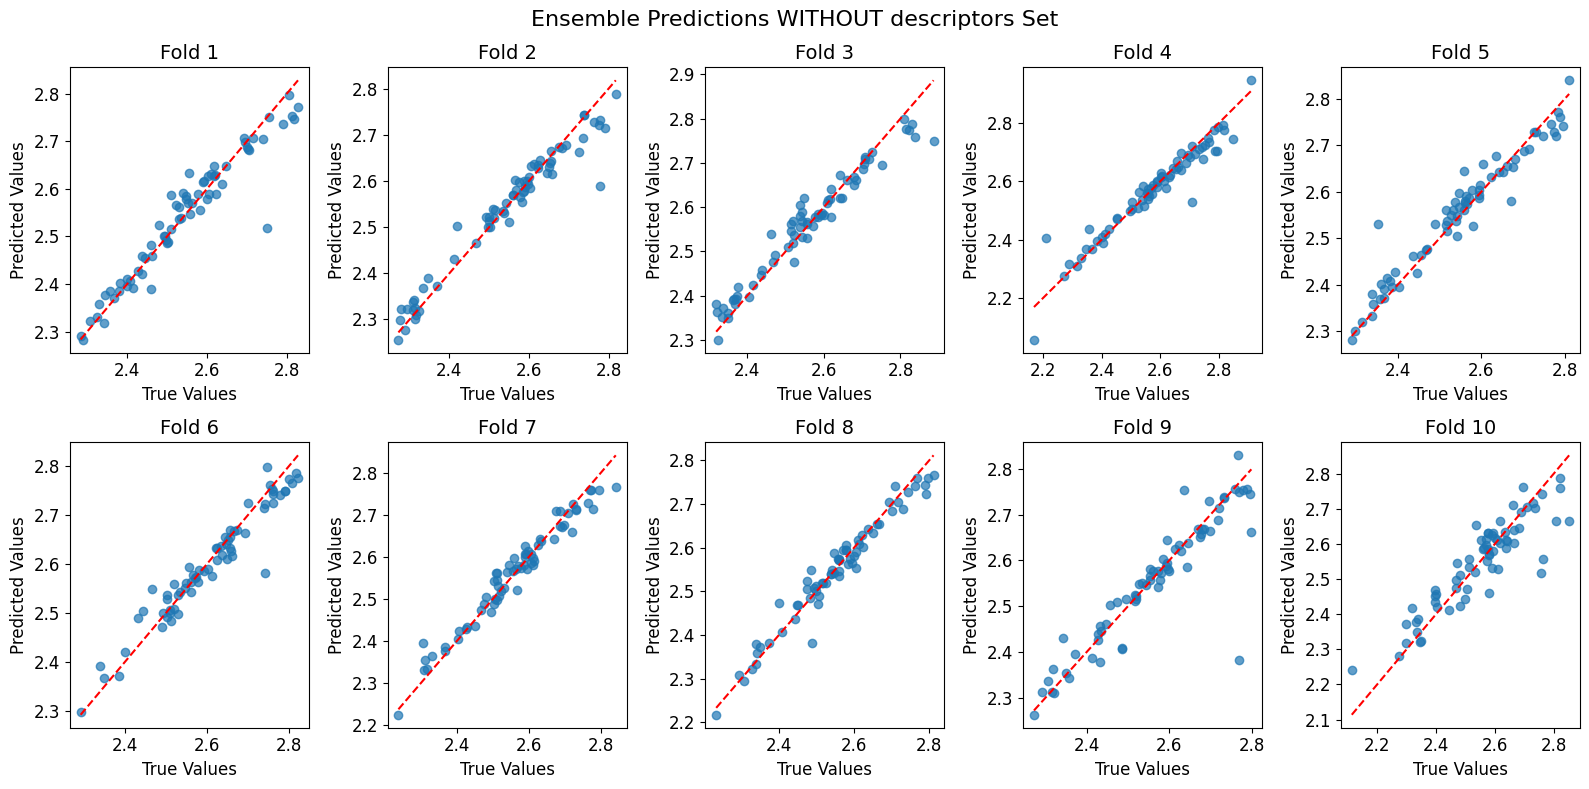

In [23]:
show_true_vs_pred_validation(
    ys_true_dict=val_ys_kfold_dict,
    ys_pred_dict=val_preds_no_desc,
    title_="WITHOUT descriptors"
)

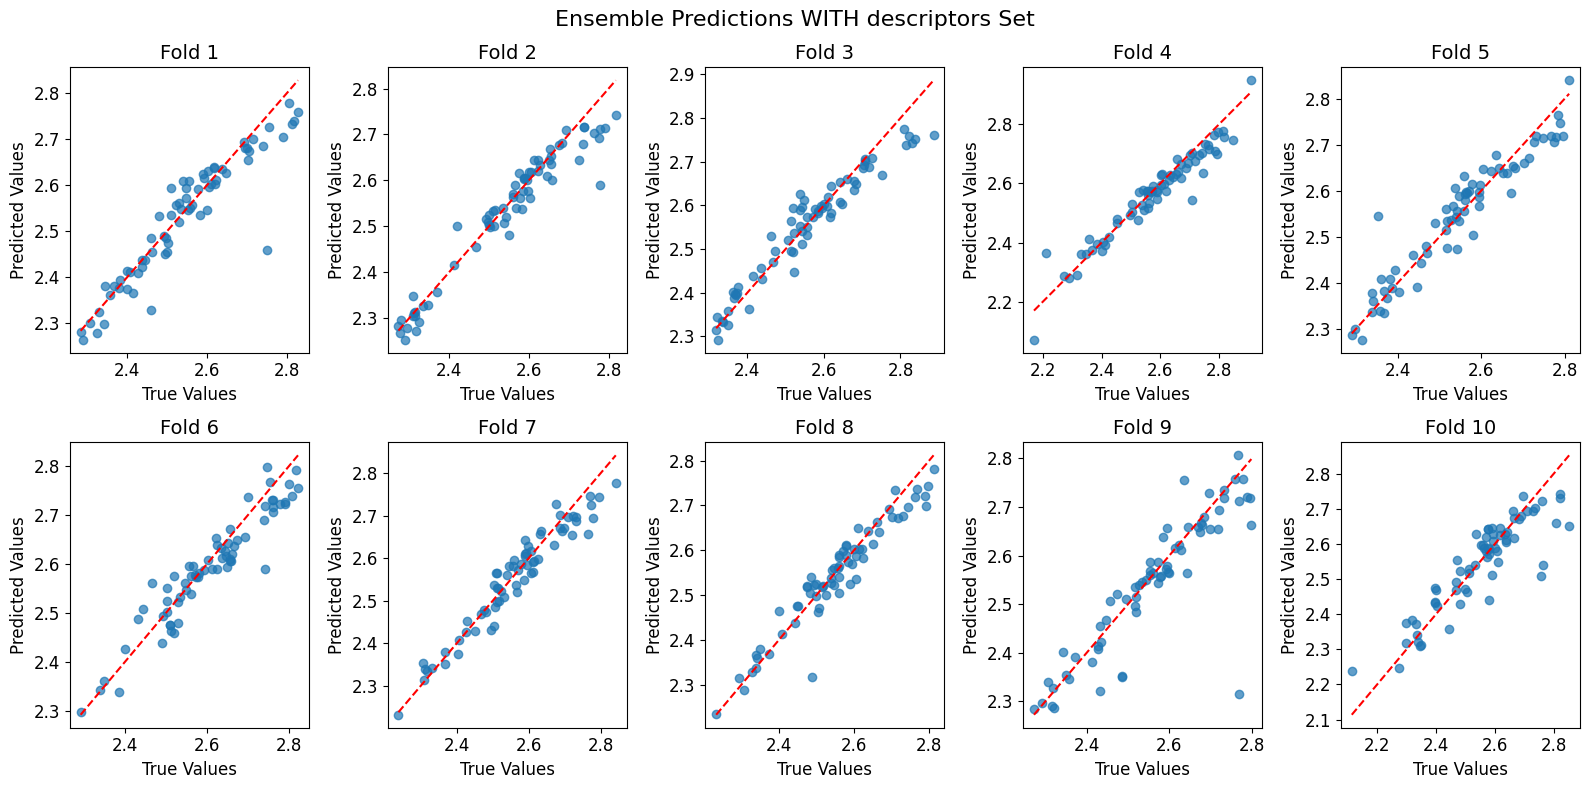

In [24]:
show_true_vs_pred_validation(
    ys_true_dict=val_ys_kfold_dict,
    ys_pred_dict=val_preds_with_desc,
    title_="WITH descriptors"
)

In [25]:
def show_true_vs_pred_test(
    ys_true,
    ys_pred,
    title_="WITH descriptors"
):
    """
    Show true vs predicted scatter plot.

    Parameters:
        ys_true: True target values
        ys_pred: Predicted target values
    """
    plt.figure(figsize=(6,6))
    plt.scatter(ys_true, ys_pred, alpha=0.7)
    plt.xlabel("True Values")
    plt.ylabel("Predicted Values")
    plt.title(f"Ensemble Predictions {title_} Set")
    plt.plot([min(ys_true), max(ys_true)], [min(ys_true), max(ys_true)], 'r--')
    plt.show()

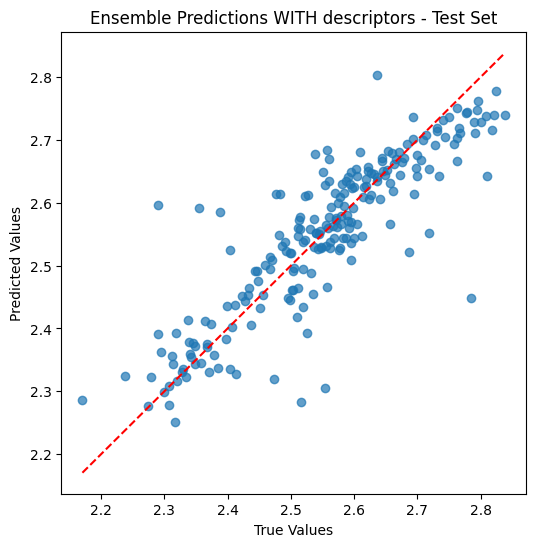

In [26]:
mean_test_preds_with_desc = np.concatenate(
    [test_preds_with_desc[k] for k in test_preds_with_desc.keys()]
).mean(axis=0)

show_true_vs_pred_test(
    ys_true=test_ys_true,
    ys_pred=mean_test_preds_with_desc,
    title_="WITH descriptors - Test"
)

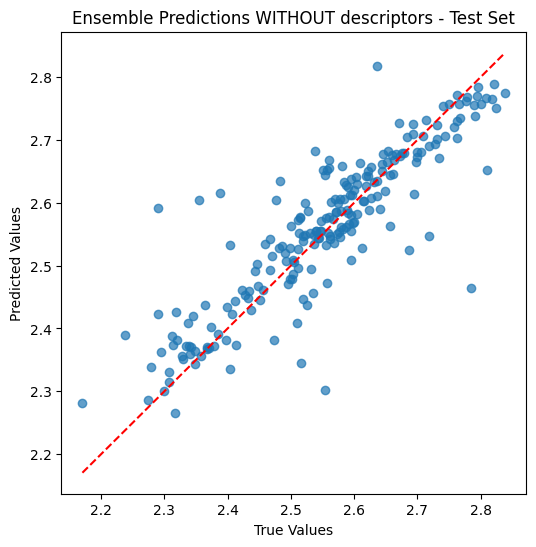

In [27]:
mean_test_preds_without_desc = np.concatenate(
    [test_preds_no_desc[k] for k in test_preds_no_desc.keys()]
).mean(axis=0)

show_true_vs_pred_test(
    ys_true=test_ys_true,
    ys_pred=mean_test_preds_without_desc,
    title_="WITHOUT descriptors - Test"
)

## Perform N Sweep Analysis

Evaluate ensemble performance as a function of N on **both validation and test sets** to demonstrate that validation-based N selection generalizes to independent test data.

In [28]:
def evaluate_ensemble_subset(
    models_dict,
    featurizer,
    train_mols_kfold_dict,
    train_ys_kfold_dict,
    test_mols_kfold_dict,
    test_ys_kfold_dict,
    dataset_name="Validation",
    n_models=10,
    train_desc_kfold_dict=None,
    test_desc_kfold_dict=None,
    n_repeats=10,
    seed=42
):
    """
    Evaluate ensemble performance for a given subset size N.
    
    Repeats sampling n_repeats times to get robust estimates.
    
    Returns dict with mean/std of metrics across repeats.
    """
    rng = np.random.default_rng(seed)
    results = []
    
    for rep in range(n_repeats):
        # Sample indices for N models randomly
        indices = rng.choice(
            len(models_dict[0]),
            size=n_models,
            replace=False
        )
        
        # Make predictions
        preds_dict = {}
        subset_models_dict = {}
        for fold_ in train_mols_kfold_dict.keys():
            # Sample N models randomly
            subset_models_dict[fold_] = [models_dict[fold_][i] for i in indices]   
            # Make predictions
            preds_dict[fold_] = predict_ensemble(
                models=subset_models_dict[fold_],
                featurizer=featurizer,
                train_mols=train_mols_kfold_dict[fold_],
                train_ys=train_ys_kfold_dict[fold_],
                train_descriptors=train_desc_kfold_dict[fold_] if train_desc_kfold_dict is not None else None,
                test_mols=test_mols_kfold_dict[fold_],
                test_ys=test_ys_kfold_dict[fold_],
                test_descriptors=test_desc_kfold_dict[fold_] if test_desc_kfold_dict is not None else None
            )
        
        if dataset_name == "Validation":
            # stack side-by-side, predictions and true values across folds
            all_preds = np.hstack(
                [preds_dict[k] for k in preds_dict.keys()],
            )
            y_true = np.hstack(
                [test_ys_kfold_dict[k] for k in test_ys_kfold_dict.keys()]
            )
        else:
            all_preds = np.concatenate(
                [preds_dict[k] for k in preds_dict.keys()],
                axis=0
            )
            y_true = test_ys_kfold_dict[0]  # assuming test set is same across folds
    
        #print("Shape prediction array shape:", all_preds.shape)
        #print("target array shape:", y_true.shape)
        preds_mean = all_preds.mean(axis=0)
        preds_std = all_preds.std(axis=0)
        
        # Compute metrics
        errors = np.abs(preds_mean - y_true)
        rmse = np.sqrt(np.mean((preds_mean - y_true)**2))
        mae = np.mean(errors)
        r2 = 1 - np.sum((preds_mean - y_true)**2) / np.sum((y_true - y_true.mean())**2)
        
        # Uncertainty correlation
        uncertainty_corr, _ = stats.spearmanr(preds_std, errors)
        
        results.append({
            'n_models': n_models,
            'repeat': rep,
            'rmse': rmse,
            'mae': mae,
            'r2': r2,
            'mean_uncertainty': preds_std.mean(),
            'uncertainty_corr': uncertainty_corr,
        })
    
    df_results = pd.DataFrame(results)
    
    return {
        'n_models': n_models,
        'rmse_mean': df_results['rmse'].mean(),
        'rmse_std': df_results['rmse'].std(),
        'mae_mean': df_results['mae'].mean(),
        'mae_std': df_results['mae'].std(),
        'r2_mean': df_results['r2'].mean(),
        'r2_std': df_results['r2'].std(),
        'uncertainty_mean': df_results['mean_uncertainty'].mean(),
        'uncertainty_std': df_results['mean_uncertainty'].std(),
        'uncertainty_corr_mean': df_results['uncertainty_corr'].mean(),
        'uncertainty_corr_std': df_results['uncertainty_corr'].std(),
    }

In [29]:
# Define N values to test
N_values = [10, 20, 30, 40, 50, 60, 70, 80, 90, 100]
n_repeats = 20  # Number of random subsets to sample for each N

print(f"Testing N values: {N_values}")
print(f"Repeats per N: {n_repeats}")

Testing N values: [10, 20, 30, 40, 50, 60, 70, 80, 90, 100]
Repeats per N: 20


### N Sweep: WITH Descriptors (Validation Set)

In [ ]:
# print("Running N sweep for WITH descriptors ensemble on VALIDATION set...")
# results_with_desc_val = []

# for n in tqdm(N_values, desc="N sweep WITH descriptors (val)"):
#     result = evaluate_ensemble_subset(
#         models_dict=models_with_desc,
#         featurizer=featurizer,
#         train_mols_kfold_dict=train_mols_kfold_dict,
#         train_ys_kfold_dict=train_ys_kfold_dict,
#         test_mols_kfold_dict=val_mols_kfold_dict,
#         test_ys_kfold_dict=val_ys_kfold_dict,
#         dataset_name="Validation",
#         n_models=n,
#         train_desc_kfold_dict=train_desc_kfold_dict,
#         test_desc_kfold_dict=val_desc_kfold_dict,
#         n_repeats=n_repeats,
#         seed=RANDOM_SEED
#     )
#     results_with_desc_val.append(result)

# df_results_with_val = pd.DataFrame(results_with_desc_val)
# print("\n✓ WITH descriptors (validation) N sweep complete")
# print(df_results_with_val[['n_models', 'rmse_mean', 'rmse_std', 'r2_mean', 'uncertainty_corr_mean']].head())

Running N sweep for WITH descriptors ensemble on VALIDATION set...


N sweep WITH descriptors (val): 100%|██████████| 10/10 [32:45<00:00, 196.57s/it]


✓ WITH descriptors (validation) N sweep complete
   n_models  rmse_mean  rmse_std   r2_mean  uncertainty_corr_mean
0        10   0.049748  0.002383  0.878670               0.176605
1        20   0.049497  0.001400  0.880062               0.180611
2        30   0.049393  0.000880  0.880618               0.185349
3        40   0.049490  0.000859  0.880149               0.197548
4        50   0.049428  0.000740  0.880462               0.197745


### N Sweep: WITHOUT Descriptors (Validation Set)

In [ ]:
# print("Running N sweep for WITHOUT descriptors ensemble on VALIDATION set...")
# results_no_desc_val = []

# for n in tqdm(N_values, desc="N sweep WITHOUT descriptors (val)"):
#     result = evaluate_ensemble_subset(
#         models_dict=models_without_desc,
#         featurizer=featurizer,
#         train_mols_kfold_dict=train_mols_kfold_dict,
#         train_ys_kfold_dict=train_ys_kfold_dict,
#         test_mols_kfold_dict=val_mols_kfold_dict,
#         test_ys_kfold_dict=val_ys_kfold_dict,
#         dataset_name="Validation",
#         n_models=n,
#         n_repeats=n_repeats,
#         seed=RANDOM_SEED
#     )
#     results_no_desc_val.append(result)

# df_results_no_val = pd.DataFrame(results_no_desc_val)
# print("\n✓ WITHOUT descriptors (validation) N sweep complete")
# print(
#     df_results_no_val[
#         ['n_models', 'rmse_mean', 'rmse_std', 'r2_mean', 'uncertainty_corr_mean']
#     ].head()
# )

Running N sweep for WITHOUT descriptors ensemble on VALIDATION set...


N sweep WITHOUT descriptors (val): 100%|██████████| 10/10 [1:09:02<00:00, 414.26s/it]


✓ WITHOUT descriptors (validation) N sweep complete
   n_models  rmse_mean  rmse_std   r2_mean  uncertainty_corr_mean
0        10   0.043328  0.001867  0.908003               0.224089
1        20   0.042564  0.001404  0.911284               0.269749
2        30   0.042595  0.000858  0.911210               0.276992
3        40   0.042621  0.001004  0.911092               0.270188
4        50   0.042681  0.000553  0.910873               0.268078


### N Sweep: WITH Descriptors (Test Set)

In [32]:
test_mols_kfold_dict={}
test_ys_kfold_dict = {}
test_desc_kfold_dict = {}
for fold_ in train_desc_kfold_dict.keys():
    test_mols_kfold_dict[fold_] = test_mols
    test_ys_kfold_dict[fold_] = test_ys_true
    test_desc_kfold_dict[fold_] = test_descriptors

In [ ]:
# print("Running N sweep for WITH descriptors ensemble on TEST set...")
# results_with_desc_test = []

# for n in tqdm(N_values, desc="N sweep WITH descriptors (test)"):
#     result = evaluate_ensemble_subset(
#         models_dict=models_with_desc,
#         featurizer=featurizer,
#         train_mols_kfold_dict=train_mols_kfold_dict,
#         train_ys_kfold_dict=train_ys_kfold_dict,
#         test_mols_kfold_dict=test_mols_kfold_dict,
#         test_ys_kfold_dict=test_ys_kfold_dict,
#         dataset_name="Test",
#         n_models=n,
#         train_desc_kfold_dict=train_desc_kfold_dict,
#         test_desc_kfold_dict=test_desc_kfold_dict,
#         n_repeats=n_repeats,
#         seed=RANDOM_SEED
#     )
#     results_with_desc_test.append(result)

# df_results_with_test = pd.DataFrame(results_with_desc_test)
# print("\n✓ WITH descriptors (test) N sweep complete")
# print(
#     df_results_with_test[
#         ['n_models', 'rmse_mean', 'rmse_std', 'r2_mean', 'uncertainty_corr_mean']
#     ].head()
# )

Running N sweep for WITH descriptors ensemble on TEST set...


N sweep WITH descriptors (test):  60%|██████    | 6/10 [3:03:21<2:02:14, 1833.65s/it]


SystemExit: 1

### N Sweep: WITHOUT Descriptors (Test Set)

In [ ]:
# print("Running N sweep for WITHOUT descriptors ensemble on TEST set...")
# results_no_desc_test = []

# for n in tqdm(N_values, desc="N sweep WITHOUT descriptors (test)"):
#     result = evaluate_ensemble_subset(
#         models_dict=models_without_desc,
#         featurizer=featurizer,
#         train_mols_kfold_dict=train_mols_kfold_dict,
#         train_ys_kfold_dict=train_ys_kfold_dict,
#         test_mols_kfold_dict=test_mols_kfold_dict,
#         test_ys_kfold_dict=test_ys_kfold_dict,
#         dataset_name="Test",
#         n_models=n,
#         n_repeats=n_repeats,
#         seed=RANDOM_SEED
#     )
#     results_no_desc_test.append(result)

# df_results_no_test = pd.DataFrame(results_no_desc_test)

# print("\n WITHOUT descriptors (test) N sweep complete")

# print(
#     df_results_no_test[
#         ['n_models', 'rmse_mean', 'rmse_std', 'r2_mean', 'uncertainty_corr_mean']
#     ].head()
# )

# Load Results

In [36]:
results_dir = PROJECT_ROOT / "data" / "processed" / "ensemble_analysis"

df_results_with_val = pd.read_csv(results_dir / "n_sweep_with_descriptors_val.csv")
df_results_no_val = pd.read_csv(results_dir / "n_sweep_without_descriptors_val.csv")
df_results_with_test = pd.read_csv(results_dir / "n_sweep_with_descriptors_test.csv")
df_results_no_test = pd.read_csv(results_dir / "n_sweep_without_descriptors_test.csv")

## Visualizations: Validation vs Test Comparison

Compare ensemble performance convergence on validation and test sets to demonstrate generalization.

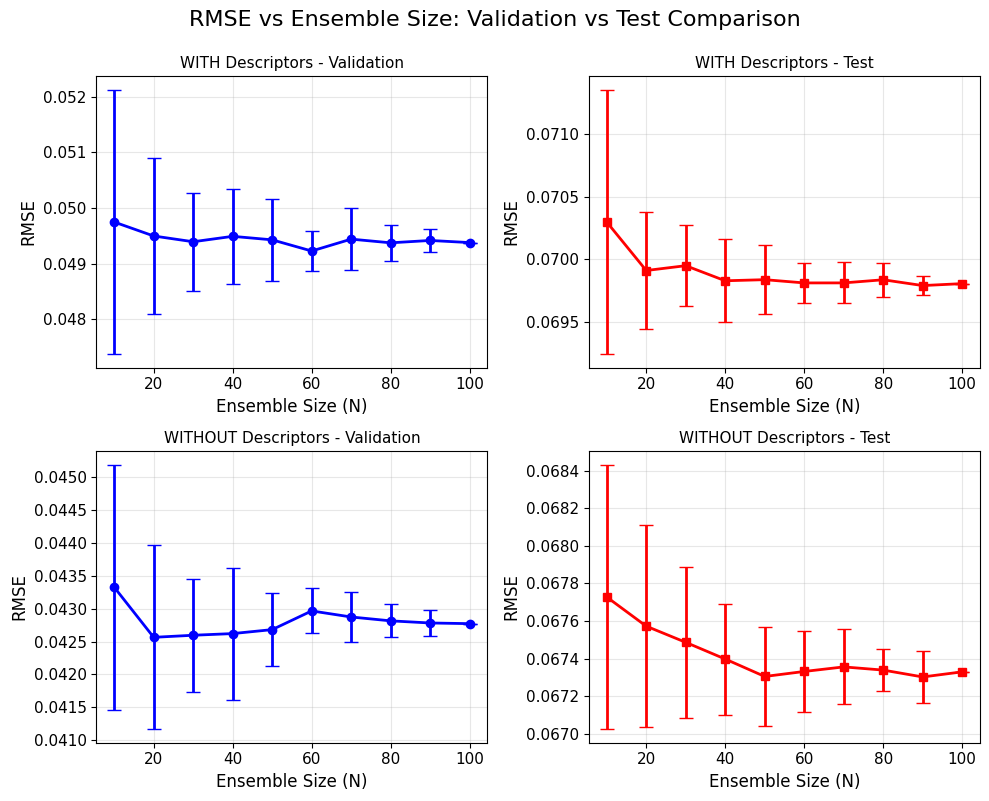

In [37]:
fig, axes = plt.subplots(2, 2, figsize=(10, 8))

# WITH descriptors - Validation
ax = axes[0, 0]
ax.tick_params(axis='both', which='major', labelsize=11)
ax.errorbar(
    df_results_with_val['n_models'],
    df_results_with_val['rmse_mean'],
    yerr=df_results_with_val['rmse_std'],
    marker='o',
    capsize=5,
    color='blue',
    linewidth=2,
)
ax.set_xlabel('Ensemble Size (N)', fontsize=12)
ax.set_ylabel('RMSE', fontsize=12)
ax.set_title('WITH Descriptors - Validation', fontsize=11)
ax.grid(True, alpha=0.3)

# WITH descriptors - Test
ax = axes[0, 1]
ax.tick_params(axis='both', which='major', labelsize=11)
ax.errorbar(
    df_results_with_test['n_models'],
    df_results_with_test['rmse_mean'],
    yerr=df_results_with_test['rmse_std'],
    marker='s',
    capsize=5,
    color='red',
    linewidth=2,
)
ax.set_xlabel('Ensemble Size (N)', fontsize=12)
ax.set_ylabel('RMSE', fontsize=12)
ax.set_title('WITH Descriptors - Test', fontsize=11)
ax.grid(True, alpha=0.3)

# WITHOUT descriptors - Validation
ax = axes[1, 0]
ax.tick_params(axis='both', which='major', labelsize=11)
ax.errorbar(
    df_results_no_val['n_models'],
    df_results_no_val['rmse_mean'],
    yerr=df_results_no_val['rmse_std'],
    marker='o',
    capsize=5,
    color='blue',
    linewidth=2,
)
ax.set_xlabel('Ensemble Size (N)', fontsize=12)
ax.set_ylabel('RMSE', fontsize=12)
ax.set_title('WITHOUT Descriptors - Validation', fontsize=11)
ax.grid(True, alpha=0.3)

# WITHOUT descriptors - Test
ax = axes[1, 1]
ax.tick_params(axis='both', which='major', labelsize=11)
ax.errorbar(
    df_results_no_test['n_models'],
    df_results_no_test['rmse_mean'],
    yerr=df_results_no_test['rmse_std'],
    marker='s',
    capsize=5,
    color='red',
    linewidth=2,
)
ax.set_xlabel('Ensemble Size (N)', fontsize=12)
ax.set_ylabel('RMSE', fontsize=12)
ax.set_title('WITHOUT Descriptors - Test', fontsize=11)
ax.grid(True, alpha=0.3)

plt.suptitle('RMSE vs Ensemble Size: Validation vs Test Comparison', fontsize=16, y=0.995)
plt.tight_layout()
plt.savefig(figs_dir / "rmse_vs_ensemble_size_validation_vs_test.png", dpi=300, bbox_inches='tight')
plt.show()

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


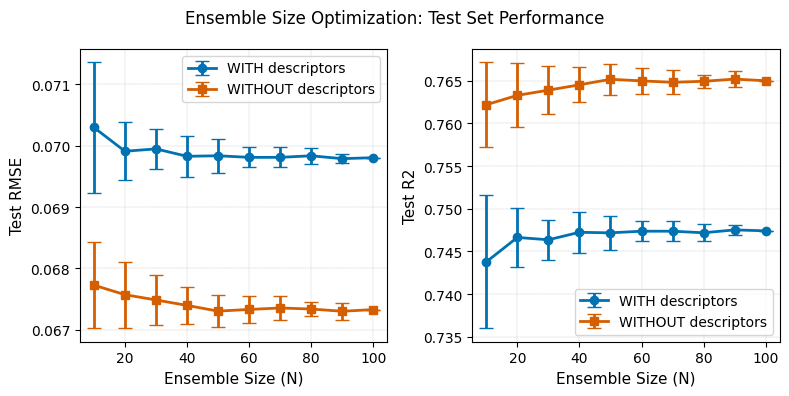

In [56]:
# Plot 2: Test Set - WITH vs WITHOUT Descriptors
plt.figure(figsize=(8, 4))
plt.subplot(1, 2, 1)
plt.errorbar(
    df_results_with_test['n_models'],
    df_results_with_test['rmse_mean'],
    yerr=df_results_with_test['rmse_std'],
    marker='o',
    capsize=5,
    label='WITH descriptors',
    color='#0072B2', # strong blue
    linewidth=2,
)

plt.errorbar(
    df_results_no_test['n_models'],
    df_results_no_test['rmse_mean'],
    yerr=df_results_no_test['rmse_std'],
    marker='s',
    capsize=5,
    label='WITHOUT descriptors',
    color='#D55E00', # vermilion
    linewidth=2,
)

plt.xlabel('Ensemble Size (N)', fontsize=11)
plt.ylabel('Test RMSE', fontsize=11)
plt.grid(True, linestyle='--', linewidth=0.25)
plt.legend(fontsize=10)
plt.subplot(1, 2, 2)
plt.errorbar(
    df_results_with_test['n_models'],
    df_results_with_test['r2_mean'],
    yerr=df_results_with_test['r2_std'],
    marker='o',
    capsize=5,
    label='WITH descriptors',
    color='#0072B2', # strong blue
    linewidth=2,
)
plt.errorbar(
    df_results_no_test['n_models'],
    df_results_no_test['r2_mean'],
    yerr=df_results_no_test['r2_std'],
    marker='s',
    capsize=5,
    label='WITHOUT descriptors',
    color='#D55E00', # vermilion
    linewidth=2,
)

plt.xlabel('Ensemble Size (N)', fontsize=11)
plt.ylabel('Test R2', fontsize=11)
plt.grid(True, linestyle='--', linewidth=0.25)
plt.legend(fontsize=10)
plt.suptitle('Ensemble Size Optimization: Test Set Performance', fontsize=12)
plt.tight_layout()
plt.savefig(
    figs_dir / "ensemble_n_sweep_combined_test_revised.eps",
    dpi=400,
    bbox_inches='tight'
)
plt.show()

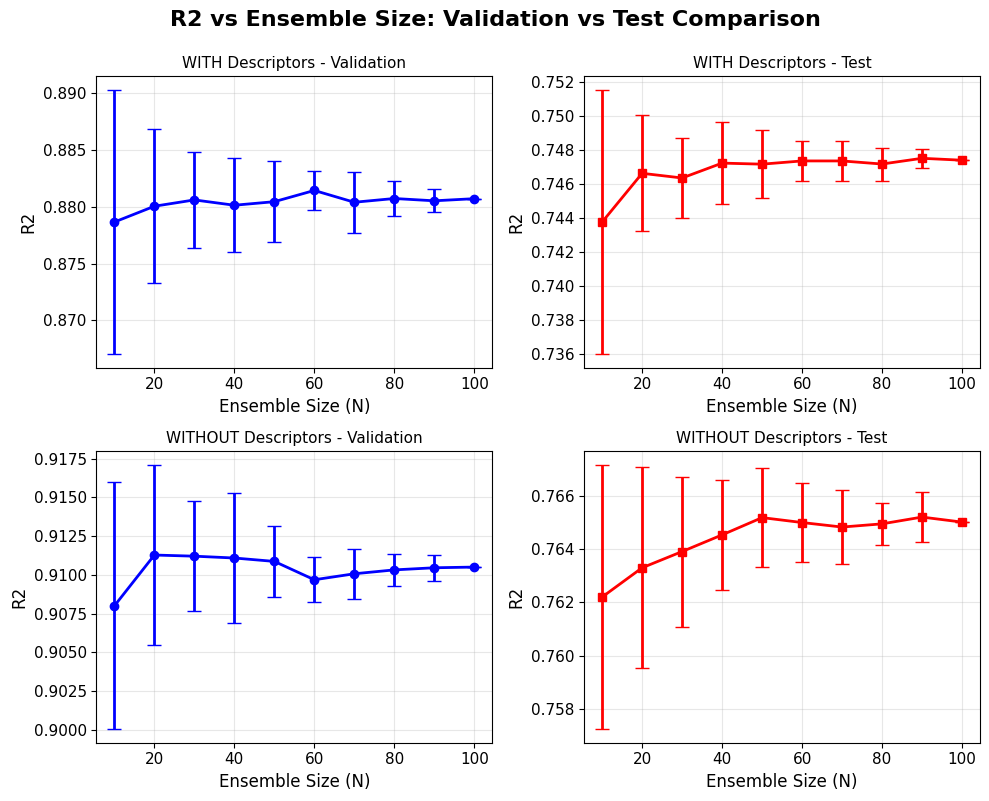

In [51]:
fig, axes = plt.subplots(2, 2, figsize=(10, 8))

# WITH descriptors - Validation
ax = axes[0, 0]
ax.tick_params(axis='both', which='major', labelsize=11)
ax.errorbar(
    df_results_with_val['n_models'],
    df_results_with_val['r2_mean'],
    yerr=df_results_with_val['r2_std'],
    marker='o',
    capsize=5,
    color='blue',
    linewidth=2,
)
ax.set_xlabel('Ensemble Size (N)', fontsize=12)
ax.set_ylabel('R2', fontsize=12)
ax.set_title('WITH Descriptors - Validation', fontsize=11)
ax.grid(True, alpha=0.3)

# WITH descriptors - Test
ax = axes[0, 1]
ax.tick_params(axis='both', which='major', labelsize=11)
ax.errorbar(
    df_results_with_test['n_models'],
    df_results_with_test['r2_mean'],
    yerr=df_results_with_test['r2_std'],
    marker='s',
    capsize=5,
    color='red',
    linewidth=2,
)
ax.set_xlabel('Ensemble Size (N)', fontsize=12)
ax.set_ylabel('R2', fontsize=12)
ax.set_title('WITH Descriptors - Test', fontsize=11)
ax.grid(True, alpha=0.3)

# WITHOUT descriptors - Validation
ax = axes[1, 0]
ax.tick_params(axis='both', which='major', labelsize=11)
ax.errorbar(
    df_results_no_val['n_models'],
    df_results_no_val['r2_mean'],
    yerr=df_results_no_val['r2_std'],
    marker='o',
    capsize=5,
    color='blue',
    linewidth=2,
)
ax.set_xlabel('Ensemble Size (N)', fontsize=12)
ax.set_ylabel('R2', fontsize=12)
ax.set_title('WITHOUT Descriptors - Validation', fontsize=11)
ax.grid(True, alpha=0.3)

# WITHOUT descriptors - Test
ax = axes[1, 1]
ax.tick_params(axis='both', which='major', labelsize=11)
ax.errorbar(
    df_results_no_test['n_models'],
    df_results_no_test['r2_mean'],
    yerr=df_results_no_test['r2_std'],
    marker='s',
    capsize=5,
    color='red',
    linewidth=2,
)
ax.set_xlabel('Ensemble Size (N)', fontsize=12)
ax.set_ylabel('R2', fontsize=12)
ax.set_title('WITHOUT Descriptors - Test', fontsize=11)
ax.grid(True, alpha=0.3)

plt.suptitle('R2 vs Ensemble Size: Validation vs Test Comparison', fontsize=16, fontweight='bold', y=0.995)
plt.savefig(figs_dir / "r2_vs_ensemble_size_validation_vs_test.png", dpi=300, bbox_inches='tight')
plt.tight_layout()
plt.show()

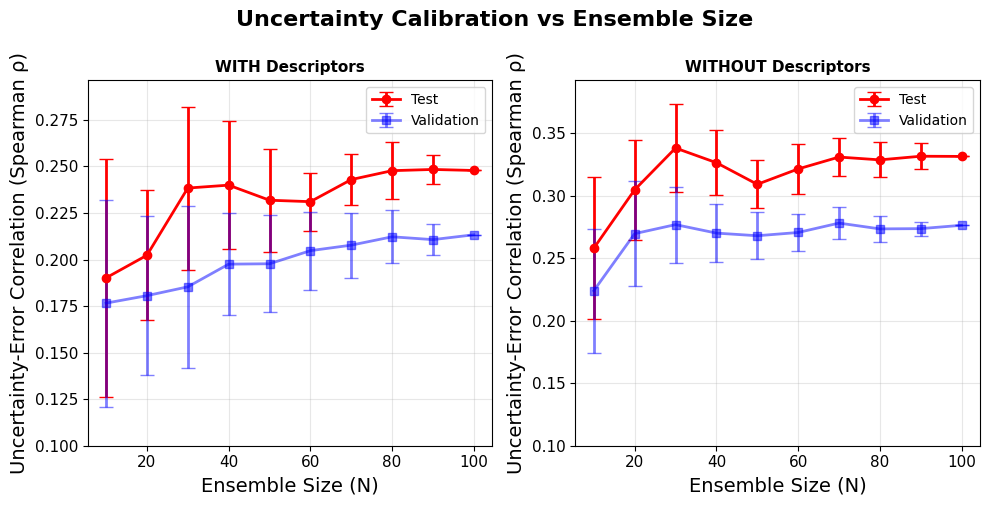

In [ ]:
# Plot 4: Uncertainty correlation vs N (Test Set)
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

for i, ax in enumerate(axes):
    ax.tick_params(axis='both', which='major', labelsize=11)
    if i == 0:
        df_results_val = df_results_with_val
        df_results_test = df_results_with_test
        title_str = "WITH Descriptors"
    else:
        df_results_val = df_results_no_val
        df_results_test = df_results_no_test
        title_str = "WITHOUT Descriptors"
    
    ax.errorbar(
        df_results_test['n_models'],
        df_results_test['uncertainty_corr_mean'],
        yerr=df_results_test['uncertainty_corr_std'],
        marker='o',
        capsize=5,
        label='Test',
        color='red',
        linewidth=2,
    )
    ax.errorbar(
        df_results_val['n_models'],
        df_results_val['uncertainty_corr_mean'],
        yerr=df_results_val['uncertainty_corr_std'],
        marker='s',
        capsize=5,
        label='Validation',
        color='blue',
        linewidth=2,
        alpha=0.5,
    )
    ax.set_xlabel('Ensemble Size (N)', fontsize=14)
    ax.set_ylabel('Uncertainty-Error Correlation (Spearman ρ)', fontsize=14)
    ax.set_title(title_str, fontsize=11, fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=10)
    ax.axhline(y=0, color='black', linestyle='--', alpha=0.3)
    ax.set_ylim(bottom=0.1)
plt.suptitle('Uncertainty Calibration vs Ensemble Size', fontsize=16, fontweight='bold', y=1.00)
plt.savefig(
    figs_dir / "uncertainty_correlation_vs_ensemble_size_validation_vs_test.png",
    dpi=300,
    bbox_inches='tight'
)
plt.tight_layout()
plt.show()

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


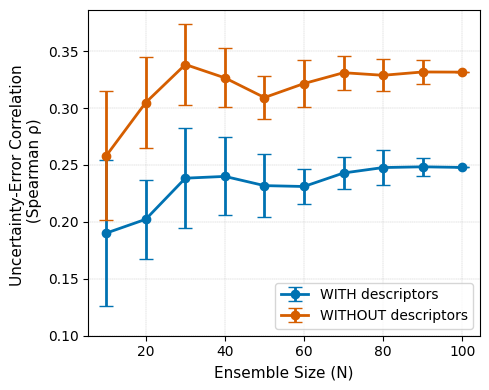

In [67]:
# Plot 4: Uncertainty correlation vs N (Test Set)
fig, ax = plt.subplots(figsize=(5, 4))   
ax.errorbar(
    df_results_with_test['n_models'],
    df_results_with_test['uncertainty_corr_mean'],
    yerr=df_results_with_test['uncertainty_corr_std'],
    marker='o',
    capsize=5,
    label='WITH descriptors',
    color='#0072B2', # strong blue
    linewidth=2,
)
ax.errorbar(
    df_results_no_test['n_models'],
    df_results_no_test['uncertainty_corr_mean'],
    yerr=df_results_no_test['uncertainty_corr_std'],
    marker='o',
    capsize=5,
    label='WITHOUT descriptors',
    color='#D55E00', # vermilion
    linewidth=2,
)    
ax.set_xlabel('Ensemble Size (N)', fontsize=11)
ax.set_ylabel('Uncertainty-Error Correlation \n (Spearman ρ)', fontsize=11)
ax.grid(True, linestyle='--', linewidth=0.25)
ax.legend(fontsize=10)
ax.set_ylim(bottom=0.1)
plt.tight_layout()
plt.savefig(
    figs_dir / "ensemble_n_sweep_uncertainty_corr_test_revised.eps",
    format='eps',
    dpi=400,
    bbox_inches='tight'
)
plt.show()

## Summary and Optimal N Selection

In [41]:
# Find elbow point (largest improvement per additional model)
def find_elbow_point(df, metric='rmse_mean'):
    """Find elbow using second derivative (curvature)"""
    x = df['n_models'].values
    y = df[metric].values
    
    # Compute first and second derivatives (finite differences)
    dy = np.diff(y) / np.diff(x)
    d2y = np.diff(dy) / np.diff(x[:-1])
    
    # Find point of maximum curvature (elbow)
    if metric.startswith('rmse') or metric.startswith('mae'):
        # For metrics where lower is better, look for where improvement slows
        elbow_idx = np.argmax(d2y) + 1  # +1 because of double diff
    else:
        # For R² (higher is better)
        elbow_idx = np.argmin(d2y) + 1
    
    return int(x[elbow_idx])

# Find elbow points on validation data
elbow_with = find_elbow_point(df_results_with_val, 'rmse_mean')
elbow_no = find_elbow_point(df_results_no_val, 'rmse_mean')

print("=" * 80)
print("ENSEMBLE N SWEEP RESULTS: VALIDATION vs TEST")
print("=" * 80)
print(f"\nOptimal N (elbow point based on validation):")
print(f"  WITH descriptors: N = {elbow_with}")
print(f"  WITHOUT descriptors: N = {elbow_no}")

ENSEMBLE N SWEEP RESULTS: VALIDATION vs TEST

Optimal N (elbow point based on validation):
  WITH descriptors: N = 60
  WITHOUT descriptors: N = 20


In [42]:
def print_elbow_info(
    df_results,
    elbow_n,
    label=""
):
    """"""
    row = df_results[df_results['n_models'] == elbow_n].iloc[0]
    print(f"\n{label} Elbow Point (N={elbow_n}):")
    print(f"  RMSE: {row['rmse_mean']:.4f} ± {row['rmse_std']:.4f}")
    print(f"  R²:   {row['r2_mean']:.4f} ± {row['r2_std']:.4f}")
    print(f"  Uncertainty Correlation: {row['uncertainty_corr_mean']:.4f} ± {row['uncertainty_corr_std']:.4f}")

# Performance at optimal N
with_val_row = df_results_with_val[df_results_with_val['n_models'] == elbow_with].iloc[0]
with_test_row = df_results_with_test[df_results_with_test['n_models'] == elbow_with].iloc[0]
no_val_row = df_results_no_val[df_results_no_val['n_models'] == elbow_no].iloc[0]
no_test_row = df_results_no_test[df_results_no_test['n_models'] == elbow_no].iloc[0]

print(f"\n{'='*80}")
print(f"Performance at optimal N:")
print(f"{'='*80}")

print(f"\nWITH descriptors (N={elbow_with}):")
print_elbow_info(df_results_with_val, elbow_with, label="WITH Descriptors - Validation")
print_elbow_info(df_results_with_test, elbow_with, label="WITH Descriptors - Test")

print(f"\nWITHOUT descriptors (N={elbow_no}):")
print_elbow_info(df_results_no_val, elbow_no, label="WITHOUT Descriptors - Validation")
print_elbow_info(df_results_no_test, elbow_no, label="WITHOUT Descriptors - Test")

# Performance at N=100 (full ensemble)
print(f"\n{'='*80}")
print(f"Performance at N=100 (full ensemble):")
print(f"{'='*80}")

print(f"\nWITH descriptors (N=100):")
print_elbow_info(df_results_with_val, 100, label="WITH Descriptors - Validation")
print_elbow_info(df_results_with_test, 100, label="WITH Descriptors - Test")

print(f"\nWITHOUT descriptors (N=100):")
print_elbow_info(df_results_no_val, 100, label="WITHOUT Descriptors - Validation")
print_elbow_info(df_results_no_test, 100, label="WITHOUT Descriptors - Test")


Performance at optimal N:

WITH descriptors (N=60):

WITH Descriptors - Validation Elbow Point (N=60):
  RMSE: 0.0492 ± 0.0004
  R²:   0.8815 ± 0.0017
  Uncertainty Correlation: 0.2048 ± 0.0209

WITH Descriptors - Test Elbow Point (N=60):
  RMSE: 0.0698 ± 0.0002
  R²:   0.7474 ± 0.0012
  Uncertainty Correlation: 0.2311 ± 0.0155

WITHOUT descriptors (N=20):

WITHOUT Descriptors - Validation Elbow Point (N=20):
  RMSE: 0.0426 ± 0.0014
  R²:   0.9113 ± 0.0058
  Uncertainty Correlation: 0.2698 ± 0.0418

WITHOUT Descriptors - Test Elbow Point (N=20):
  RMSE: 0.0676 ± 0.0005
  R²:   0.7633 ± 0.0038
  Uncertainty Correlation: 0.3049 ± 0.0399

Performance at N=100 (full ensemble):

WITH descriptors (N=100):

WITH Descriptors - Validation Elbow Point (N=100):
  RMSE: 0.0494 ± 0.0000
  R²:   0.8807 ± 0.0000
  Uncertainty Correlation: 0.2133 ± 0.0000

WITH Descriptors - Test Elbow Point (N=100):
  RMSE: 0.0698 ± 0.0000
  R²:   0.7474 ± 0.0000
  Uncertainty Correlation: 0.2479 ± 0.0000

WITHOUT d

## Save Results

In [ ]:
# # Save results to CSV
# results_dir = PROJECT_ROOT / "data" / "processed" / "ensemble_analysis"
# results_dir.mkdir(exist_ok=True, parents=True)

# # Save validation results
# df_results_with_val.to_csv(results_dir / "n_sweep_with_descriptors_val.csv", index=False)
# df_results_no_val.to_csv(results_dir / "n_sweep_without_descriptors_val.csv", index=False)

# # Save test results
# df_results_with_test.to_csv(results_dir / "n_sweep_with_descriptors_test.csv", index=False)
# df_results_no_test.to_csv(results_dir / "n_sweep_without_descriptors_test.csv", index=False)